# Transfer Learning para Clasificación de Imágenes de Soldadura
## Clases: Soldadura buena, soldadura mala y defecto

Dataset obtenido en Kaggle: https://www.kaggle.com/datasets/sukmaadhiwijaya/welding-defect-object-detection?resource=download

Conjunto de datos de detección de objetos para detectar defectos en superficies de soldadura. Contiene tres clases: soldadura defectuosa, soldadura correcta y defecto.
Este conjunto de datos está formateado para la tarea de detección de objetos en formato de anotación YOLO. El mapa de etiquetas se encuentra en el archivo data.yaml y las imágenes provienen de diversas colecciones de imágenes y conjuntos de datos.

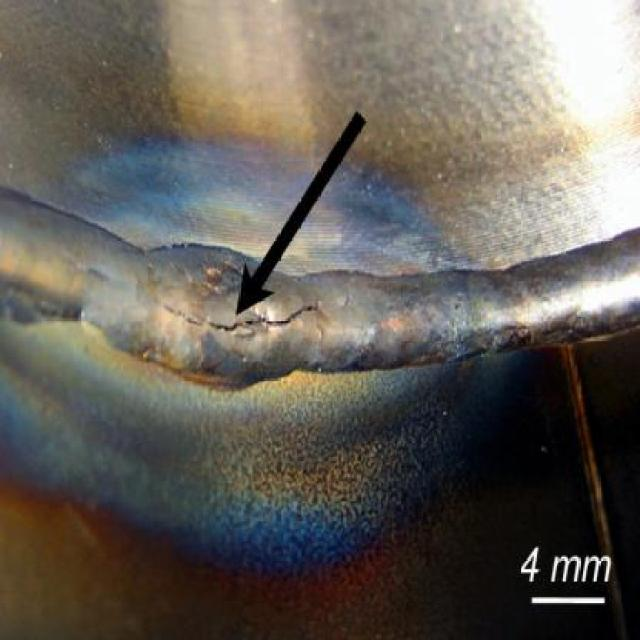

Subir kaggle.json


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/sukmaadhiwijaya/welding-defect-object-detection
License(s): CC0-1.0
 66% 101M/152M [00:00<00:00, 1.06GB/s]
100% 152M/152M [00:00<00:00, 888MB/s] 


100%|██████████| 3117/3117 [00:15<00:00, 199.93it/s]


 Clases:
 label
good_weld    1541
bad_weld     1159
defect        417
Name: count, dtype: int64
Train: 2181, Val: 468, Test: 468

 EfficientNetB0 - 5% descongelado
Epoch 1/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 50s 401ms/step - accuracy: 0.5128 - loss: 0.9760 - val_accuracy: 0.7350 - val_loss: 0.6444
Epoch 2/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.7577 - loss: 0.6162 - val_accuracy: 0.7842 - val_loss: 0.5232
Epoch 3/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.8188 - loss: 0.4860 - val_accuracy: 0.8376 - val_loss: 0.4482
Epoch 4/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.8431 - loss: 0.4260 - val_accuracy: 0.8611 - val_loss: 0.3998
Epoch 5/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.8608 - loss: 0.3691 - val_accuracy: 0.8761 - val_loss: 0.3618
 Accuracy: 0.863

 EfficientNetB0 - 20% descongelado
Epoch 1/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 59s 450ms/step - accuracy: 0.4664 - loss: 1.0061 - val_accuracy: 0.7329 - val_loss: 0.6615
Epoch 2/5
69/69 ━━━━━━━

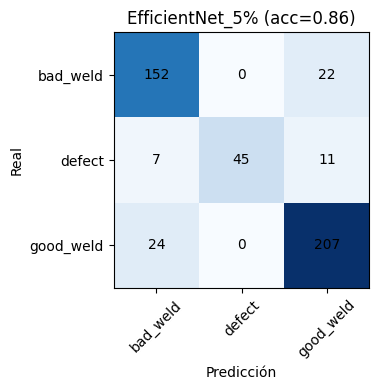

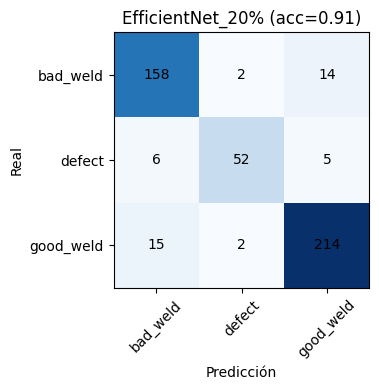

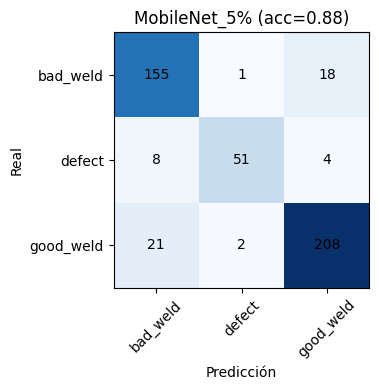

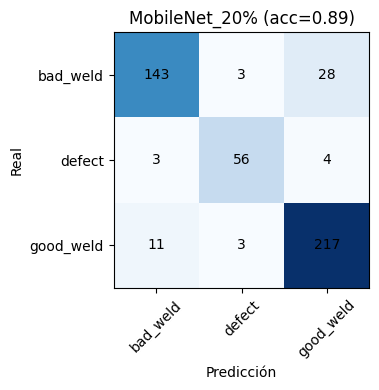

In [ ]:
## CLASIFICACIÓN DE IMÁGENES DE SOLDADURA ##
import os, zipfile, numpy as np, pandas as pd, tensorflow as tf, cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from pathlib import Path

#1. CONFIGURACIÓN KAGGLE
print("Subir kaggle.json")
from google.colab import files
uploaded = files.upload()
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

#2. DESCARGAR DATASET
!kaggle datasets download -d sukmaadhiwijaya/welding-defect-object-detection -p /content --unzip
data_root = Path('/content')

#3. CONSTRUIR DATAFRAME
labels = list((data_root).rglob("labels/*.txt"))
images = list((data_root).rglob("images/*.jpg")) + list((data_root).rglob("images/*.png"))
class_map = {0:"bad_weld", 1:"good_weld", 2:"defect"}

def find_label(img_path):
    stem = Path(img_path).stem
    for l in labels:
        if Path(l).stem == stem:
            return l
    return None

img_label = []
for img in tqdm(images):
    lab = find_label(img)
    if not lab: continue
    lines = open(lab).read().strip().splitlines()
    if not lines: continue
    best_cls, best_area = None, -1
    for L in lines:
        parts = L.split()
        if len(parts)<5: continue
        cls, w, h = int(parts[0]), float(parts[3]), float(parts[4])
        if w*h > best_area:
            best_cls, best_area = cls, w*h
    img_label.append((str(img), class_map[best_cls]))

df = pd.DataFrame(img_label, columns=['filepath','label'])
print(" Clases:\n", df['label'].value_counts())

train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

#4. PIPELINE CON PREPROCESAMIENTO
IMG_SIZE = 224
BATCH = 32
class_names = sorted(df['label'].unique())
label_to_idx = {n:i for i,n in enumerate(class_names)}

# usar el preprocesamiento específico de cada modelo
def preprocess_efficientnet(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img, label

def preprocess_mobilenet(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img, label

def df_to_ds(df, preprocess_fn):
    paths = df['filepath'].values
    labels = [label_to_idx[l] for l in df['label']]
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    return ds.shuffle(len(paths)).map(preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH).prefetch(tf.data.AUTOTUNE)

#5. CREAR MODELOS
def make_efficientnet(unfreeze_pct=20):
    base = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        pooling='avg',
        input_shape=(IMG_SIZE,IMG_SIZE,3)
    )
    for layer in base.layers:
        layer.trainable = False
    n_unfreeze = int(len(base.layers) * unfreeze_pct / 100)
    for l in base.layers[-n_unfreeze:]:
        l.trainable = True

    x = tf.keras.layers.Dense(128, activation='relu')(base.output)
    x = tf.keras.layers.Dropout(0.3)(x)
    out = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)
    model = tf.keras.Model(base.input, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def make_mobilenet(unfreeze_pct=20):
    base = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights='imagenet',
        pooling='avg',
        input_shape=(IMG_SIZE,IMG_SIZE,3)
    )
    for layer in base.layers:
        layer.trainable = False
    n_unfreeze = int(len(base.layers) * unfreeze_pct / 100)
    for l in base.layers[-n_unfreeze:]:
        l.trainable = True

    x = tf.keras.layers.Dense(128, activation='relu')(base.output)
    x = tf.keras.layers.Dropout(0.3)(x)
    out = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)
    model = tf.keras.Model(base.input, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

#6. ENTRENAR MODELOS
results = {}

# EfficientNet con 5% y 20%
for pct in [5, 20]:
    print(f"\n EfficientNetB0 - {pct}% descongelado")
    model = make_efficientnet(pct)
    train_ds = df_to_ds(train_df, preprocess_efficientnet)
    val_ds = df_to_ds(val_df, preprocess_efficientnet)
    test_ds = df_to_ds(test_df, preprocess_efficientnet)

    hist = model.fit(train_ds, validation_data=val_ds, epochs=5, verbose=1)

    y_true, y_pred = [], []
    for x, y in test_ds:
        preds = model.predict(x, verbose=0)
        y_true.extend(y.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    results[f'EfficientNet_{pct}%'] = (model, acc, cm, 'efficientnet')
    print(f" Accuracy: {acc:.3f}")

# MobileNetV2 con 5% y 20%
for pct in [5, 20]:
    print(f"\n MobileNetV2 - {pct}% descongelado")
    model = make_mobilenet(pct)
    train_ds = df_to_ds(train_df, preprocess_mobilenet)
    val_ds = df_to_ds(val_df, preprocess_mobilenet)
    test_ds = df_to_ds(test_df, preprocess_mobilenet)

    hist = model.fit(train_ds, validation_data=val_ds, epochs=5, verbose=1)

    y_true, y_pred = [], []
    for x, y in test_ds:
        preds = model.predict(x, verbose=0)
        y_true.extend(y.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    results[f'MobileNet_{pct}%'] = (model, acc, cm, 'mobilenet')
    print(f" Accuracy: {acc:.3f}")

#7. MATRIZ DE CONFUSIÓN
def plot_cm(cm, classes, title):
    plt.figure(figsize=(5,4))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xticks(range(len(classes)), classes, rotation=45)
    plt.yticks(range(len(classes)), classes)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i,j], ha='center', va='center', color='black')
    plt.xlabel('Predicción'); plt.ylabel('Real')
    plt.tight_layout(); plt.show()

for name,(model,acc,cm,_) in results.items():
    plot_cm(cm, class_names, f"{name} (acc={acc:.2f})")

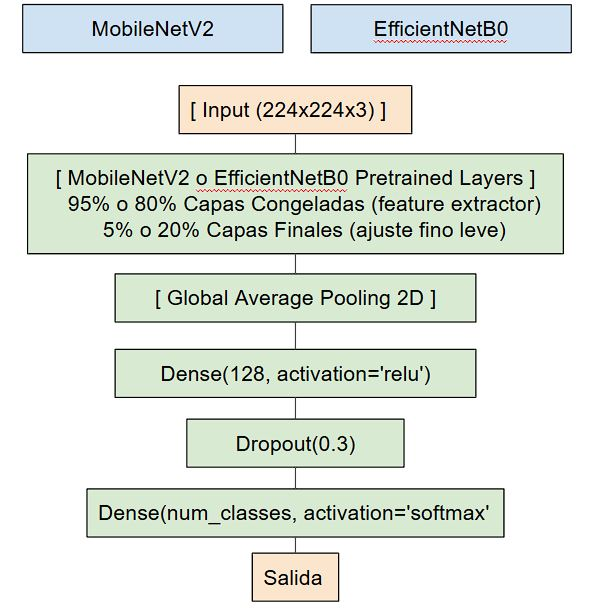


 Grad-CAM para todos los modelos con la misma imagen de ejemplo:

EfficientNet_5% (Accuracy: 0.897)
Usando capa: top_conv


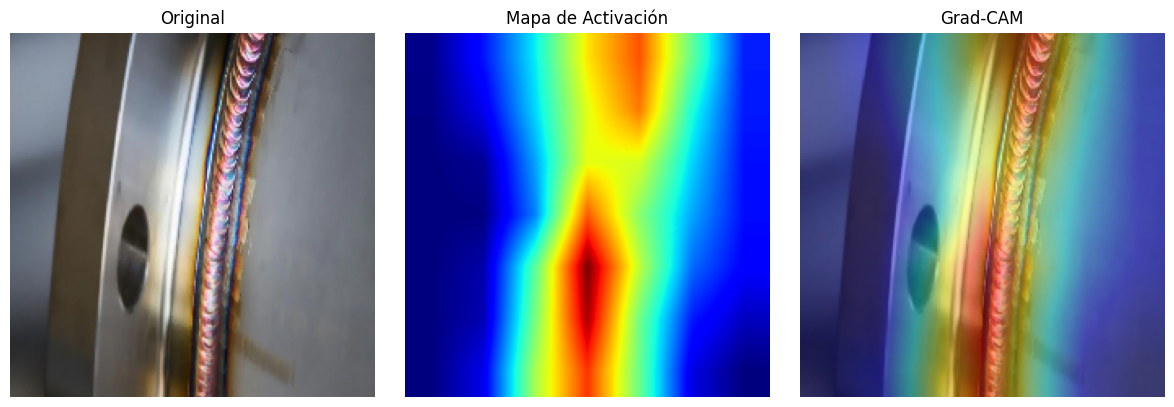


EfficientNet_20% (Accuracy: 0.949)
Usando capa: top_conv


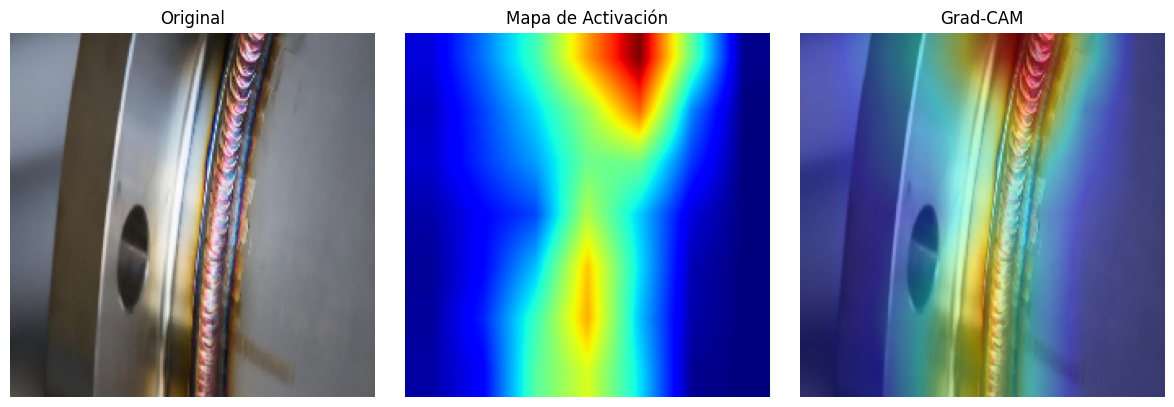


MobileNet_5% (Accuracy: 0.893)
Usando capa: Conv_1_bn


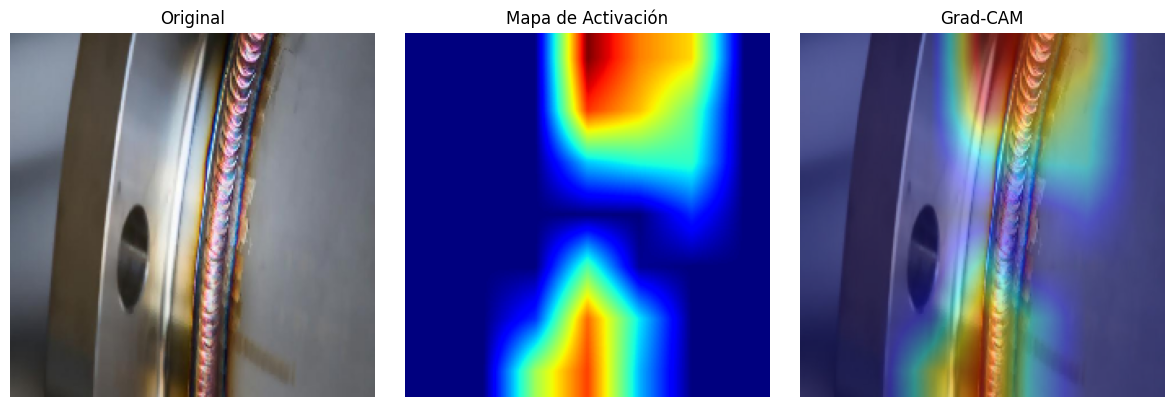


MobileNet_20% (Accuracy: 0.878)
Usando capa: Conv_1_bn


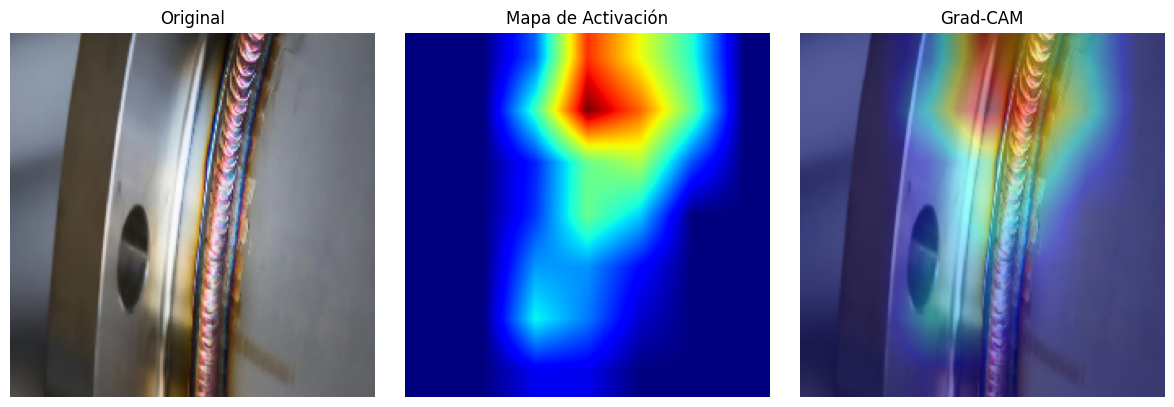

In [ ]:
# 8. GRAD-CAM
def gradcam(img_path, model, model_type):
    # Detectar última capa convolucional
    last_conv = None
    for layer in reversed(model.layers):
        if 'conv' in layer.name.lower():
            last_conv = layer.name
            break

    if not last_conv:
        print(" No se encontró capa convolucional")
        return

    print(f"Usando capa: {last_conv}")

    # Cargar imagen con preprocesamiento correcto
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = tf.keras.preprocessing.image.img_to_array(img)

    if model_type == 'efficientnet':
        arr = tf.keras.applications.efficientnet.preprocess_input(arr)
    else:
        arr = tf.keras.applications.mobilenet_v2.preprocess_input(arr)
    arr = np.expand_dims(arr, axis=0)

    # Modelo Grad-CAM
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv).output, model.output]
    )

    # Calcular gradientes
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(arr)
        idx = tf.argmax(preds[0])
        loss = preds[:, idx]

    grads = tape.gradient(loss, conv_out)[0]
    weights = tf.reduce_mean(grads, axis=(0, 1))

    # Crear mapa de calor
    cam = np.zeros(conv_out.shape[1:3], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * conv_out[0, :, :, i].numpy()

    cam = np.maximum(cam, 0)
    cam = cam / (np.max(cam) + 1e-8)
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

    # Superponer mapa de calor
    img_original = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_original = tf.keras.preprocessing.image.img_to_array(img_original) / 255.0

    heat = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat.astype(np.uint8), cv2.COLOR_BGR2RGB) / 255.0
    overlay = img_original * 0.6 + heat * 0.4

    # Mostrar
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img_original)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(cam, cmap='jet')
    plt.title("Mapa de Activación")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Grad-CAM")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Aplicar Grad-CAM a TODOS los modelos
example = test_df['filepath'].iloc[7]

print(f"\n Grad-CAM para todos los modelos con la misma imagen de ejemplo:")
for name, (model, acc, _, model_type) in results.items():
    print(f"\n{'='*60}")
    print(f"{name} (Accuracy: {acc:.3f})")
    print(f"{'='*60}")
    gradcam(example, model, model_type)

#Grad-CAM
Grad-CAM (Gradient-weighted Class Activation Mapping) visualiza las regiones de la imagen que más influyen en la predicción del modelo.

Funcionamiento:
1. Se calcula el gradiente de la clase predicha respecto a la última capa conv.
2. Se promedian los gradientes por canal para obtener pesos de importancia
3. Se combinan los mapas de activación con estos pesos"
4. Se genera un mapa de calor que muestra las zonas más relevantes
5. Las zonas 'calientes' (rojas) son las que el modelo 'mira' para decidir

# Conclusiones

| Modelo | % Capas Descongeladas | Tipo de Fine-Tuning | Accuracy | Observaciones |
|:--------|:----------------------:|:--------------------|:----------:|:--------------|
| **EfficientNet_5%** | 5% | Ajuste leve (solo últimas capas) | **0.897** | Buen desempeño, rápido |
| **EfficientNet_20%** | 20% | Ajuste moderado (más capas activas) | **0.949** | **Mejor modelo global**, logra la mayor precisión |
| **MobileNet_5%** | 5% | Ajuste leve (pocas capas) | **0.893** | Similar a EfficientNet_5%, |
| **MobileNet_20%** | 20% | Ajuste moderado (más capas activas) | **0.878** | Ligeramente peor |


Al aprovechar técnicas de transfer learning, se logra aprovechar redes preentrenadas como EfficientNet y MobileNetV2 para obtener resultados precisos con un volumen limitado de datos. Esta técnica acelera el desarrollo de modelos robustos, reduce el costo computacional y facilita la adaptación a problemas específicos como la detección de soldaduras buenas, malas y con defecto, lo que podría permitir una inspección rápida, consistente y escalable, reduciendo errores humanos y mejorando la seguridad estructural.

Además, la implementación de Grad-CAM aporta datos de suma importancia al visualizar las regiones de la imagen que influyen en la decisión del modelo. Esto ayuda a mejorar la confianza en el sistema y valida que el modelo esté poniendo atención a las zonas relevantes de la soldadura, por lo cual un modelo de este tipo podría ayudar a automatizar el control de calidad en procesos industriales, identificando defectos como grietas, porosidad o falta de penetración con alta precisión.